In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
%cd /content/drive/Othercomputers/LG DX 노트북/LG_Dx_School/Machine Learning/1.텍스트 마이닝

/content/drive/Othercomputers/LG DX 노트북/LG_Dx_School/Machine Learning/1.텍스트 마이닝


In [5]:
!pwd

/content/drive/Othercomputers/LG DX 노트북/LG_Dx_School/Machine Learning/1.텍스트 마이닝


In [6]:
# Mecab 설치하기
!git clone https://github.com/SOMJANG/Mecab-ko-for-Google-Colab.git
!bash ./Mecab-ko-for-Google-Colab/install_mecab-ko_on_colab_light_220429.sh

fatal: destination path 'Mecab-ko-for-Google-Colab' already exists and is not an empty directory.
Installing konlpy.....
Done
Installing mecab-0.996-ko-0.9.2.tar.gz.....
from https://bitbucket.org/eunjeon/mecab-ko/downloads/mecab-0.996-ko-0.9.2.tar.gz
--2026-02-23 05:33:47--  https://bitbucket.org/eunjeon/mecab-ko/downloads/mecab-0.996-ko-0.9.2.tar.gz
Resolving bitbucket.org (bitbucket.org)... 104.192.142.24, 104.192.142.26, 104.192.142.25, ...
Connecting to bitbucket.org (bitbucket.org)|104.192.142.24|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-02-23 05:33:47 ERROR 404: Not Found.

Done
Unpacking mecab-0.996-ko-0.9.2.tar.gz.......
Done
Change Directory to mecab-0.996-ko-0.9.2.......
./Mecab-ko-for-Google-Colab/install_mecab-ko_on_colab_light_220429.sh: line 23: cd: mecab-0.996-ko-0.9.2/: No such file or directory
installing mecab-0.996-ko-0.9.2.tar.gz........
configure
make
make check
make install
ldconfig
Done
Change Directory to /content
from https:

In [6]:
#mecab 형태소 분석기 활용하여 토큰화
from konlpy.tag import Mecab
mecab = Mecab()

### 3.문서연관성
- Doc2Vec
    - 문서간의 유사도를 계산하여 고정된 크기의 벡터로 변환하는 도구 
    - 문서간의 유사도를 학습하는 도구
    - 활용예시
        - 뉴스기사 1개 -> 비슷한 뉴스기사 추출
        - 리뷰 -> 비슷한 감성의 리뷰 추출
        - 영화 -> 사용자가 좋아하는 영화 줄거리를 학습하여 유사한 주제의 영화 추천

- 기업 공시데이터를 활용하여 문서 유사도 확인 실습
    - 유사한 기업 확인

In [7]:
import pandas as pd

In [8]:
dart_data = pd.read_csv("./데이터/dart.csv")

In [9]:
dart_data.head()

,code,market,name,business
0,000020,KOSPI,동화약품,II. 사업의 내용\n1. 사업의 개요\n가. 일반적인 사항\n기업회계기준서 제11...
1,000040,KOSPI,KR모터스,II. 사업의 내용\n1. 사업의 개요\n가. 업계의 현황\n수출주력시장인 유럽 불...
2,000050,KOSPI,경방,II. 사업의 내용\n1. 사업의 개요\n(1) 산업의 특성\n[섬유사업부문]\n면...
3,000060,KOSPI,메리츠화재,"II. 사업의 내용\n1. 사업의 개요\n가. 산업의 특성, 성장성, 경기변동의 특..."
4,000070,KOSPI,삼양홀딩스,"II. 사업의 내용\n1. 사업의 개요\n가. 업계의 현황\n지주회사(持株會社, H..."


In [14]:
dart_data['business'][0]

'II. 사업의 내용\n1. 사업의 개요\n가. 일반적인 사항\n기업회계기준서 제1110호 "연결재무제표"의 의하여 2018년 12월 17일에 설립한 동화크립톤기업가정신 제일호 창업벤처전문 사모투자합자회사를 종속회사에 편입하였습니다.\n나. 지배기업의 현황\n1) 산업의 특성\n제약산업은 약학, 화학, 생물학 등 여러 분야의 지식과 기술이 복합적으로 필요한 기술 ·지식 집약형 산업으로 인간의 생명과 보건에 직접적으로 관련된 제품을 생산하 고, 개발 ·제조 ·유통 ·가격 등을 정부에서 엄격하게 규제하고 관리하는 산업적 특성을 가지고 있습니다. 또한 신약 개발에는 막대한 시간과 비용이 소요되며, 성공 확률 또한 높지 않으나 신약 개발에 성공 할 경우엔 엄청난 부가가치를 창출할 수 있는 미래 성장산업으로 분류되고 있습니다.\n2) 산업의 성장성\n제약산업은 고령화시대의 핵심적인 분야로서 웰빙 경향 등 건강한 노후생활에 대한\xa0 관심이 고조되면서 지속적인 성장이 유망한 산업으로 인식되고 있습니다. 고령화\xa0 \xa0\xa0 사회로의 진입, 경제수준의 향상, 난치병 치료를 위한 생명공학을 기반으로 하는 신\xa0 약의 개발 등은 국내제약산업의 계속적인 성장을 기대하게 하는 중요한 요소입니다.\n3) 경기변동의 특성 및 계절성\n제약산업은 산업경기 측면에서 수요탄력성이 낮고, 경기흐름의 영향을 덜 받는 특성을 가지고 있습니다. 의약품은 크게 일반의약품(OTC)와 전문의약품(ETC)로 구분되며 전문의약품은 의약분업 이후 크게 성장하고 있으며, 일반의약품에 비해 경기변동과 계절적요인 등에 영향을 받지 않습니다. 일반의약품의 경우에는 전문의약품 보다는 좀더 경기변동과 계절적요인에 따른 영향을 받고 있습니다.\n4) 경쟁요소\n자본의 영세성으로 인하여 시장진입이 비교적 용이한 완전 경쟁시장으로 자본력, 신약개발력, 오리지널 의약품의 강점을 보유한 외국계 제약사들이 시장에서 약진하고 있으며 원료의약품, 신약개발, 바이오산업의 형태로 대기업의 진출이 가속화 되고\xa0\xa

In [15]:
dart_data['name'].unique

<bound method Series.unique of 0             동화약품
1            KR모터스
2               경방
3            메리츠화재
4            삼양홀딩스
           ...    
2584        코오롱티슈진
2585           JTC
2586           SNK
2587           미투젠
2588    소마젠(Reg.S)
Name: name, Length: 2589, dtype: object>

In [16]:
dart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2589 entries, 0 to 2588
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   code      2589 non-null   object
 1   market    2589 non-null   object
 2   name      2589 non-null   object
 3   business  2295 non-null   object
dtypes: object(4)
memory usage: 81.0+ KB


In [17]:
# 결측치 제거
dart_data.dropna(inplace=True)

In [18]:
dart_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2295 entries, 0 to 2586
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   code      2295 non-null   object
 1   market    2295 non-null   object
 2   name      2295 non-null   object
 3   business  2295 non-null   object
dtypes: object(4)
memory usage: 89.6+ KB


In [19]:
# 데이터 크기확인
dart_data.shape

(2295, 4)

In [20]:
dart_data['business'][0]

'II. 사업의 내용\n1. 사업의 개요\n가. 일반적인 사항\n기업회계기준서 제1110호 "연결재무제표"의 의하여 2018년 12월 17일에 설립한 동화크립톤기업가정신 제일호 창업벤처전문 사모투자합자회사를 종속회사에 편입하였습니다.\n나. 지배기업의 현황\n1) 산업의 특성\n제약산업은 약학, 화학, 생물학 등 여러 분야의 지식과 기술이 복합적으로 필요한 기술 ·지식 집약형 산업으로 인간의 생명과 보건에 직접적으로 관련된 제품을 생산하 고, 개발 ·제조 ·유통 ·가격 등을 정부에서 엄격하게 규제하고 관리하는 산업적 특성을 가지고 있습니다. 또한 신약 개발에는 막대한 시간과 비용이 소요되며, 성공 확률 또한 높지 않으나 신약 개발에 성공 할 경우엔 엄청난 부가가치를 창출할 수 있는 미래 성장산업으로 분류되고 있습니다.\n2) 산업의 성장성\n제약산업은 고령화시대의 핵심적인 분야로서 웰빙 경향 등 건강한 노후생활에 대한\xa0 관심이 고조되면서 지속적인 성장이 유망한 산업으로 인식되고 있습니다. 고령화\xa0 \xa0\xa0 사회로의 진입, 경제수준의 향상, 난치병 치료를 위한 생명공학을 기반으로 하는 신\xa0 약의 개발 등은 국내제약산업의 계속적인 성장을 기대하게 하는 중요한 요소입니다.\n3) 경기변동의 특성 및 계절성\n제약산업은 산업경기 측면에서 수요탄력성이 낮고, 경기흐름의 영향을 덜 받는 특성을 가지고 있습니다. 의약품은 크게 일반의약품(OTC)와 전문의약품(ETC)로 구분되며 전문의약품은 의약분업 이후 크게 성장하고 있으며, 일반의약품에 비해 경기변동과 계절적요인 등에 영향을 받지 않습니다. 일반의약품의 경우에는 전문의약품 보다는 좀더 경기변동과 계절적요인에 따른 영향을 받고 있습니다.\n4) 경쟁요소\n자본의 영세성으로 인하여 시장진입이 비교적 용이한 완전 경쟁시장으로 자본력, 신약개발력, 오리지널 의약품의 강점을 보유한 외국계 제약사들이 시장에서 약진하고 있으며 원료의약품, 신약개발, 바이오산업의 형태로 대기업의 진출이 가속화 되고\xa0\xa

In [21]:
len(dart_data['business'][0])

25330

In [22]:
from tqdm import tqdm

- 형태소 단위로 분리

In [23]:
from konlpy.tag import Mecab
mecab = Mecab()

In [24]:
business_morphs = [mecab.morphs(doc) for doc in tqdm(dart_data['business'])] # 형태소 단위로 분할된 doc 데이터를 담을 리스트


100%|██████████| 2295/2295 [01:42<00:00, 22.43it/s]


In [34]:
# 이 코드로 실행해도 가능!
business_morphs_1 = []
for doc in tqdm(dart_data['business']): # 회사 소개 데이터 반복
    rs = mecab.morphs(doc)
    business_morphs_1.append(rs)

100%|██████████| 2295/2295 [01:45<00:00, 21.79it/s]


In [25]:
len(business_morphs)

2295

In [26]:
dart_data['형태소 분리'] = business_morphs

In [27]:
dart_data.head()

,code,market,name,business,형태소 분리
0,000020,KOSPI,동화약품,II. 사업의 내용\n1. 사업의 개요\n가. 일반적인 사항\n기업회계기준서 제11...,"[II, ., 사업, 의, 내용, 1, ., 사업, 의, 개요, 가, ., 일반, ..."
1,000040,KOSPI,KR모터스,II. 사업의 내용\n1. 사업의 개요\n가. 업계의 현황\n수출주력시장인 유럽 불...,"[II, ., 사업, 의, 내용, 1, ., 사업, 의, 개요, 가, ., 업계, ..."
2,000050,KOSPI,경방,II. 사업의 내용\n1. 사업의 개요\n(1) 산업의 특성\n[섬유사업부문]\n면...,"[II, ., 사업, 의, 내용, 1, ., 사업, 의, 개요, (, 1, ), 산..."
3,000060,KOSPI,메리츠화재,"II. 사업의 내용\n1. 사업의 개요\n가. 산업의 특성, 성장성, 경기변동의 특...","[II, ., 사업, 의, 내용, 1, ., 사업, 의, 개요, 가, ., 산업, ..."
4,000070,KOSPI,삼양홀딩스,"II. 사업의 내용\n1. 사업의 개요\n가. 업계의 현황\n지주회사(持株會社, H...","[II, ., 사업, 의, 내용, 1, ., 사업, 의, 개요, 가, ., 업계, ..."


- 문서의 유사도를 확인하기 위해, 문서와 문서 Id를 활용
- TaggedDocument : "문서"와 "문서ID"를 묶어 Doc2Vec 학습용 구조로 변경

In [28]:
!pip install gensim

In [29]:
from gensim.models.doc2vec import Doc2Vec , TaggedDocument

In [31]:
d2v_data = [] # 문서ID와 문서가 연결된 데이터를 담을 리스트
for doc,doc_id in zip(dart_data['형태소 분리'],dart_data['name']):
    tagged_doc = TaggedDocument(tags=[doc_id],words=doc) # 기업명과 공시 텍스트를 쌍으로 묶어주는 작업
    d2v_data.append(tagged_doc)

In [32]:
d2v_data[0]

TaggedDocument(words=['II', '.', '사업', '의', '내용', '1', '.', '사업', '의', '개요', '가', '.', '일반', '적', '인', '사항', '기업', '회계', '기준', '서', '제', '1110', '호', '"', '연결', '재무제표', '"', '의', '의하', '여', '2018', '년', '12', '월', '17', '일', '에', '설립', '한', '동화', '크립톤', '기업가', '정신', '제일', '호', '창업', '벤처', '전문', '사모', '투자', '합자회사', '를', '종속', '회사', '에', '편입', '하', '였', '습니다', '.', '나', '.', '지배', '기업', '의', '현황', '1', ')', '산업', '의', '특성', '제약', '산업', '은', '약학', ',', '화학', ',', '생물학', '등', '여러', '분야', '의', '지식', '과', '기술', '이', '복합', '적', '으로', '필요', '한', '기술', '·', '지식', '집약', '형', '산업', '으로', '인간', '의', '생명', '과', '보건', '에', '직접', '적', '으로', '관련', '된', '제품', '을', '생산', '하', '고', ',', '개발', '·', '제조', '·', '유통', '·', '가격', '등', '을', '정부', '에서', '엄격', '하', '게', '규제', '하', '고', '관리', '하', '는', '산업', '적', '특성', '을', '가지', '고', '있', '습니다', '.', '또한', '신약', '개발', '에', '는', '막대', '한', '시간', '과', '비용', '이', '소요', '되', '며', ',', '성공', '확률', '또한', '높', '지', '않', '으나', '신약', '개발', '에', '성공', '할', '경우', '엔', '엄청난

- 형태소 분석과 tags=['기업이름'] 기업명을 매칭시켜놓은 데이터셋

- Doc2Vec 모델 학습하기

In [35]:
len(d2v_data[0][0])

10806

In [36]:
# 모델생성
d2v = Doc2Vec(vector_size = 300, # 문서를 수치화할 때 사용하는 차원의 크기
               window = 8, # 학습시 주변 단어의 범위를 설정하는 파라미터
               )

In [37]:
# 단어사전 구축
d2v.build_vocab(d2v_data)

In [38]:
# 사용하는 문서 수 확인
d2v.corpus_count

2295

In [39]:
# 단어 학습
d2v.train(d2v_data, # 학습할 데이터 셋
        epochs = 20, # 학습 횟수
        total_examples = d2v.corpus_count # 사용하는 문서 수 입력
        )

In [47]:
# 모델 저장
d2v.save('./데이터/dart_model.doc2vec')

In [49]:
# 모델 불러오기
load_model = Doc2Vec.load('./데이터/dart_model.doc2vec')

In [83]:
load_model.dv.most_similar("하이트진로",topn=20)

[('하이트진로홀딩스', 0.8903771042823792),
 ('보해양조', 0.6371024250984192),
 ('무학', 0.6145957708358765),
 ('롯데칠성', 0.5658330321311951),
 ('국순당', 0.49852877855300903),
 ('샘표식품', 0.4783899188041687),
 ('해태제과식품', 0.46106353402137756),
 ('진로발효', 0.46104660630226135),
 ('한국팩키지', 0.4560934901237488),
 ('PN풍년', 0.4529099464416504),
 ('해마로푸드서비스', 0.4522336423397064),
 ('삼광글라스', 0.44685089588165283),
 ('경방', 0.44476813077926636),
 ('매일유업', 0.4402572512626648),
 ('토니모리', 0.438949316740036),
 ('빙그레', 0.43536412715911865),
 ('창해에탄올', 0.4343797564506531),
 ('제로투세븐', 0.4308069050312042),
 ('크라운제과', 0.4294348359107971),
 ('농심', 0.41968268156051636)]

In [51]:
load_model.dv.most_similar("카카오게임즈",topn=20)

[('액토즈소프트', 0.6955205798149109),
 ('조이맥스', 0.6798425912857056),
 ('넵튠', 0.6766595840454102),
 ('넷마블', 0.6702425479888916),
 ('썸에이지', 0.6696885228157043),
 ('펄어비스', 0.6672617197036743),
 ('네오위즈홀딩스', 0.6639878153800964),
 ('위메이드', 0.6539624333381653),
 ('네오위즈', 0.6439898014068604),
 ('미투온', 0.6407299637794495),
 ('조이시티', 0.6349940299987793),
 ('베스파', 0.6332579851150513),
 ('컴투스', 0.6310462355613708),
 ('넷게임즈', 0.6214069724082947),
 ('아이톡시', 0.6191670298576355),
 ('NHN', 0.6183028221130371),
 ('넥슨지티', 0.6149976253509521),
 ('선데이토즈', 0.6140770316123962),
 ('더블유게임즈', 0.6093909740447998),
 ('베노홀딩스', 0.6078134775161743)]

In [53]:
load_model.dv.most_similar("카카오",topn=20)

[('네오위즈', 0.5666419267654419),
 ('카카오게임즈', 0.5658013820648193),
 ('아이톡시', 0.5570060014724731),
 ('네오위즈홀딩스', 0.5567933917045593),
 ('컴투스', 0.554262101650238),
 ('썸에이지', 0.5460991263389587),
 ('베스파', 0.5410179495811462),
 ('조이맥스', 0.5397874116897583),
 ('룽투코리아', 0.5359792709350586),
 ('위메이드', 0.5231616497039795),
 ('NHN', 0.5224432945251465),
 ('엠게임', 0.5188973546028137),
 ('아프리카TV', 0.5100771188735962),
 ('액션스퀘어', 0.5080826878547668),
 ('게임빌', 0.5062666535377502),
 ('퓨쳐스트림네트웍스', 0.5060932636260986),
 ('갤럭시아머니트리', 0.5024740695953369),
 ('넷마블', 0.5015660524368286),
 ('넵튠', 0.5002492070198059),
 ('NAVER', 0.4977157413959503)]

- 배송데이터를 활용하여 Doc2Vec 진행 후 유사한 리뷰 출력하기

In [56]:
# 네이버 쇼핑데이터 불러오기 (컬럼명설정 -> 평점, 리뷰)
rv_data = pd.read_csv("./데이터/naver_shopping.txt",sep = '\t',header = None)
rv_data.columns = ["평점","리뷰"]

In [57]:
# 리뷰데이터 전처리
rv_data

,평점,리뷰
0,5,배공빠르고 굿
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고
2,5,아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다. 바느질이 조금 ...
3,2,선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다. 전...
4,5,민트색상 예뻐요. 옆 손잡이는 거는 용도로도 사용되네요 ㅎㅎ
...,...,...
199995,2,장마라그런가!!! 달지않아요
199996,5,다이슨 케이스 구매했어요 다이슨 슈퍼소닉 드라이기 케이스 구매했어요가격 괜찮고 배송...
199997,5,로드샾에서 사는것보다 세배 저렴하네요 ㅜㅜ 자주이용할께요
199998,5,넘이쁘고 쎄련되보이네요~


In [58]:
from gensim.utils   import simple_preprocess
# 간단한 전처리 도구 -> 토큰화, 특수문자 제거 등 

In [60]:
# 리뷰데이터 전처리 -> Doc2Vec 학습을 위한 태깅작업 (문서, 문서 ID 연결과정)
# 태깅할 구분자가 없을 경우 인덱스 번호로 매칭
# enumerate() : 반복문에서 리스트를 순환하며 인덱스와 해당 값, 2개의 원소를 반환

tagged_data_1 = []
for i,rv in tqdm(enumerate(rv_data['리뷰'])): # i는 인덱스 번호, rv : 리뷰
    rs = TaggedDocument(tags = [i],words = simple_preprocess(rv)) # 리뷰데이터 토큰화도 함께 진행
    tagged_data_1.append(rs)


200000it [00:05, 35622.65it/s]


In [ ]:
tagged_data = [TaggedDocument(tags = [i],words = simple_preprocess(rv)) for i,rv in tqdm(enumerate(rv_data['리뷰'])) ]

200000it [00:07, 25652.97it/s]


In [77]:
# 모델생성
rv_model = Doc2Vec(vector_size = 50, # 문서를 수치화할 때 사용하는 차원의 크기
               window = 5, # 학습시 주변 단어의 범위를 설정하는 파라미터
               )

In [78]:
# 단어사전 구축
rv_model.build_vocab(tagged_data)

In [79]:
rv_model.corpus_count

200000

In [80]:
# 단어 학습
rv_model.train(tagged_data, # 학습할 데이터 셋
        epochs = 20, # 학습 횟수
        total_examples = rv_model.corpus_count # 사용하는 문서 수 입력
        )

In [ ]:
sim_5 = rv_model.dv.most_similar(100,topn=5)

[(80649, 0.7770429253578186),
 (154060, 0.7728511095046997),
 (110311, 0.7697699069976807),
 (56193, 0.7624947428703308),
 (191326, 0.7624302506446838)]

In [ ]:
# 비슷한 리뷰 확인
# "생각외로 모기가 안잡혀욧"
# rv_data['리뷰'][100]
sim_5 = rv_model.dv.most_similar(100,topn=5) # 태그 번호만 넣어주면 됨
print(sim_5)

[(80649, 0.7770429253578186), (154060, 0.7728511095046997), (110311, 0.7697699069976807), (56193, 0.7624947428703308), (191326, 0.7624302506446838)]


In [73]:
rv_data['리뷰'][100]

'생각외로 모기가 안잡혀요'

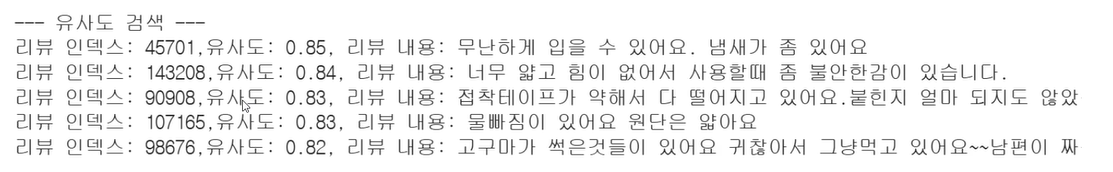

In [93]:
rv_data.iloc[sim_5[0][0],1]

'모기가 전혀 잡히지 않아요 일주일째 한마리도 못잡음'

In [96]:
sim_5[0]

(80649, 0.7770429253578186)

In [105]:
print(f"비교 문장 : {rv_data['리뷰'][100]}")

for dt in sim_5 : 
    print()
    print(f"리뷰인덱스: {dt[0]} , 유사도 : {dt[1]},\n리뷰내용 : {rv_data.iloc[dt[0],1]}")

비교 문장 : 생각외로 모기가 안잡혀요

리뷰인덱스: 80649 , 유사도 : 0.7770429253578186,
리뷰내용 : 모기가 전혀 잡히지 않아요 일주일째 한마리도 못잡음

리뷰인덱스: 154060 , 유사도 : 0.7728511095046997,
리뷰내용 : 3일쓴것같은데 아직까진 모기가 잡히지 않았어요..

리뷰인덱스: 110311 , 유사도 : 0.7697699069976807,
리뷰내용 : 전력이 약해서인지 벌레가 잘 안잡히네요

리뷰인덱스: 56193 , 유사도 : 0.7624947428703308,
리뷰내용 : 팬 돌아가는게 너무약해서 모기가 빨려들어가지않아요

리뷰인덱스: 191326 , 유사도 : 0.7624302506446838,
리뷰내용 : 켜놓고 자면 반대편에서 모기가 무는게 잘 안잡히는데요..


In [108]:
print(f"검색한 리뷰 :{rv_data['리뷰'][100]}")
print()
print("---유사한 리뷰 및 유사도 출력---")
for idx, sim in sim_5:
    print()
    print(f"리뷰인덱스: {idx} , 유사도 : {sim},\n리뷰내용 : {rv_data['리뷰'][idx]}")
    

검색한 리뷰 :생각외로 모기가 안잡혀요

---유사한 리뷰 및 유사도 출력---

리뷰인덱스: 80649 , 유사도 : 0.7770429253578186,
리뷰내용 : 모기가 전혀 잡히지 않아요 일주일째 한마리도 못잡음

리뷰인덱스: 154060 , 유사도 : 0.7728511095046997,
리뷰내용 : 3일쓴것같은데 아직까진 모기가 잡히지 않았어요..

리뷰인덱스: 110311 , 유사도 : 0.7697699069976807,
리뷰내용 : 전력이 약해서인지 벌레가 잘 안잡히네요

리뷰인덱스: 56193 , 유사도 : 0.7624947428703308,
리뷰내용 : 팬 돌아가는게 너무약해서 모기가 빨려들어가지않아요

리뷰인덱스: 191326 , 유사도 : 0.7624302506446838,
리뷰내용 : 켜놓고 자면 반대편에서 모기가 무는게 잘 안잡히는데요..


In [95]:
rv_data.iloc[sim_5[0][0],1]

'모기가 전혀 잡히지 않아요 일주일째 한마리도 못잡음'

In [ ]:
d2v_model_1 = Doc2Vec(vector_size = 50, window =5)
d2v_model_1.